# 🎬 MovieLens Collaborative Filtering Recommendation System

## Project Objective

The objective of this project is to build a movie recommendation system using the MovieLens dataset and collaborative filtering.

The project focuses on constructing a user-item rating matrix, measuring similarity between users based on their movie-rating patterns, and generating personalized movie recommendations.

### Key Objectives

- Load and analyze the MovieLens rating dataset.
- Construct a user-item rating matrix.
- Analyze the sparsity of the rating matrix.
- Calculate user similarity using cosine similarity.
- Implement user-based collaborative filtering.
- Generate personalized Top-N movie recommendations.
- Predict ratings for selected user-movie combinations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load MovieLens datasets

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Datasets loaded successfully!")
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Datasets loaded successfully!
Ratings shape: (100836, 4)
Movies shape: (9742, 3)


In [ ]:
# Display first few rows

print("Ratings Dataset:")
display(ratings.head())

print("\nMovies Dataset:")
display(movies.head())

Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# Basic dataset information

print("Number of unique users:", ratings["userId"].nunique())
print("Number of unique movies:", ratings["movieId"].nunique())
print("Total ratings:", len(ratings))

print("\nRating range:")
print(ratings["rating"].min(), "to", ratings["rating"].max())

print("\nMissing values:")
print(ratings.isnull().sum())

Number of unique users: 610
Number of unique movies: 9724
Total ratings: 100836

Rating range:
0.5 to 5.0

Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


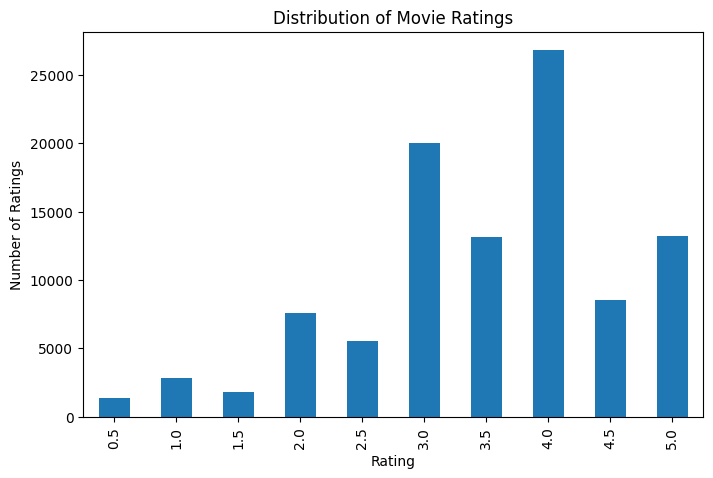

In [ ]:
# Rating distribution

plt.figure(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")

plt.show()

In [ ]:
# Build User-Item Rating Matrix

user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

print("User-Item Matrix Shape:", user_item_matrix.shape)

display(user_item_matrix.head())

User-Item Matrix Shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check missing values in User-Item Matrix

total_cells = user_item_matrix.size
missing_cells = user_item_matrix.isna().sum().sum()

print("Total cells:", total_cells)
print("Missing cells:", missing_cells)

Total cells: 5931640
Missing cells: 5830804


In [ ]:
# Calculate matrix sparsity

sparsity = missing_cells / total_cells

print(f"Matrix Sparsity: {sparsity:.2%}")

Matrix Sparsity: 98.30%


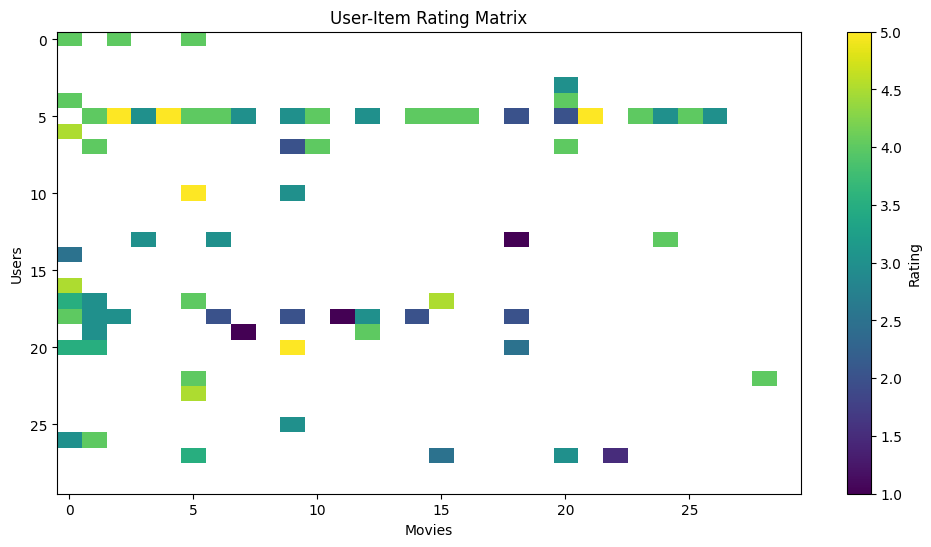

In [ ]:
# Visualize a small portion of the User-Item Matrix

plt.figure(figsize=(12, 6))

plt.imshow(
    user_item_matrix.iloc[:30, :30],
    aspect="auto"
)

plt.xlabel("Movies")
plt.ylabel("Users")
plt.title("User-Item Rating Matrix")

plt.colorbar(label="Rating")

plt.show()

In [ ]:
# Replace missing values with 0 for similarity calculation

matrix_filled = user_item_matrix.fillna(0)

print("Matrix prepared for collaborative filtering.")

Matrix prepared for collaborative filtering.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Calculate similarity between users

user_similarity = cosine_similarity(matrix_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print("User similarity matrix created!")

display(user_similarity_df.head())

User similarity matrix created!


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [ ]:
# Find users similar to User 1

target_user = 1

similar_users = user_similarity_df[target_user].sort_values(
    ascending=False
)

print("Most similar users to User 1:")
display(similar_users.head(10))

Most similar users to User 1:


,1
userId,
1,1.000000
266,0.357408
313,0.351562
368,0.345127
57,0.345034
91,0.334727
469,0.330664
39,0.329782
288,0.329700


In [ ]:
similar_users = similar_users.drop(target_user)

print("Top similar users:")
display(similar_users.head(10))

Top similar users:


,1
userId,
266,0.357408
313,0.351562
368,0.345127
57,0.345034
91,0.334727
469,0.330664
39,0.329782
288,0.329700
452,0.328048


In [ ]:
def recommend_movies(user_id, n=10, k=10):

    # Get similarity scores for the selected user
    similarities = user_similarity_df[user_id].drop(user_id)

    # Select top K similar users
    similar_users = similarities.sort_values(
        ascending=False
    ).head(k)

    # Movies already rated by target user
    user_ratings = user_item_matrix.loc[user_id]

    rated_movies = set(
        user_ratings[user_ratings.notna()].index
    )

    # Store recommendation scores
    scores = {}

    # Collect highly rated movies from similar users
    for similar_user, similarity in similar_users.items():

        similar_user_ratings = user_item_matrix.loc[similar_user]

        for movie_id, rating in similar_user_ratings.dropna().items():

            # Don't recommend movies already rated
            if movie_id not in rated_movies:

                if movie_id not in scores:
                    scores[movie_id] = 0

                scores[movie_id] += similarity * rating

    # Sort movies by recommendation score
    recommended = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:n]

    # Get movie IDs
    recommended_ids = [movie_id for movie_id, score in recommended]

    # Get movie information
    result = movies[
        movies["movieId"].isin(recommended_ids)
    ].copy()

    # Preserve recommendation order
    score_df = pd.DataFrame(
        recommended,
        columns=["movieId", "recommendation_score"]
    )

    result = result.merge(
        score_df,
        on="movieId"
    )

    result = result.sort_values(
        "recommendation_score",
        ascending=False
    )

    return result[
        ["movieId", "title", "genres", "recommendation_score"]
    ]

In [ ]:
recommendations = recommend_movies(1, n=10)

display(recommendations)

,movieId,title,genres,recommendation_score
1,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,14.182299
5,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi,13.925162
9,2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery,13.422015
7,1610,"Hunt for Red October, The (1990)",Action|Adventure|Thriller,13.377867
2,858,"Godfather, The (1972)",Crime|Drama,13.134550
3,924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi,13.031035
4,1036,Die Hard (1988),Action|Crime|Thriller,12.862273
0,541,Blade Runner (1982),Action|Sci-Fi|Thriller,12.539779
6,1221,"Godfather: Part II, The (1974)",Crime|Drama,12.104995
8,1968,"Breakfast Club, The (1985)",Comedy|Drama,12.080897


In [ ]:
recommend_movies(10, n=10)

,movieId,title,genres,recommendation_score
8,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,7.025675
7,69757,(500) Days of Summer (2009),Comedy|Drama|Romance,6.823446
5,45720,"Devil Wears Prada, The (2006)",Comedy|Drama,6.667606
9,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,6.396901
3,6539,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy,6.073271
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,5.820145
4,40815,Harry Potter and the Goblet of Fire (2005),Adventure|Fantasy|Thriller|IMAX,5.710690
2,6373,Bruce Almighty (2003),Comedy|Drama|Fantasy|Romance,5.703513
1,3793,X-Men (2000),Action|Adventure|Sci-Fi,5.377677
6,50872,Ratatouille (2007),Animation|Children|Drama,5.331712


In [ ]:
recommend_movies(50, n=10)

,movieId,title,genres,recommendation_score
3,1193,One Flew Over the Cuckoo's Nest (1975),Drama,10.469586
9,48516,"Departed, The (2006)",Crime|Drama|Thriller,9.063419
5,1213,Goodfellas (1990),Crime|Drama,9.004149
0,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,8.913650
8,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,8.893017
2,1089,Reservoir Dogs (1992),Crime|Mystery|Thriller,8.829377
7,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,8.534511
6,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,8.471713
1,527,Schindler's List (1993),Drama|War,8.453935
4,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,8.362725


In [ ]:
recommend_movies(75, n=20)

,movieId,title,genres,recommendation_score
1,110,Braveheart (1995),Action|Drama|War,7.654373
11,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,7.261465
18,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,6.761381
13,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi,6.479259
10,858,"Godfather, The (1972)",Crime|Drama,6.358516
7,527,Schindler's List (1993),Drama|War,5.682608
5,356,Forrest Gump (1994),Comedy|Drama|Romance|War,5.199322
6,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,5.045605
14,2028,Saving Private Ryan (1998),Action|Drama|War,4.962828
8,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.554153


In [ ]:
def show_recommendations(user_id, n=10):

    result = recommend_movies(user_id, n)

    print(f"\nRecommended Movies for User {user_id}")
    print("=" * 60)

    for i, row in enumerate(result.itertuples(), start=1):
        print(f"{i}. {row.title}")
        print(f"   Genres: {row.genres}")
        print(f"   Score: {row.recommendation_score:.2f}")
        print()

In [ ]:
show_recommendations(1, 10)


Recommended Movies for User 1
1. Terminator 2: Judgment Day (1991)
   Genres: Action|Sci-Fi
   Score: 14.18

2. Aliens (1986)
   Genres: Action|Adventure|Horror|Sci-Fi
   Score: 13.93

3. Sixth Sense, The (1999)
   Genres: Drama|Horror|Mystery
   Score: 13.42

4. Hunt for Red October, The (1990)
   Genres: Action|Adventure|Thriller
   Score: 13.38

5. Godfather, The (1972)
   Genres: Crime|Drama
   Score: 13.13

6. 2001: A Space Odyssey (1968)
   Genres: Adventure|Drama|Sci-Fi
   Score: 13.03

7. Die Hard (1988)
   Genres: Action|Crime|Thriller
   Score: 12.86

8. Blade Runner (1982)
   Genres: Action|Sci-Fi|Thriller
   Score: 12.54

9. Godfather: Part II, The (1974)
   Genres: Crime|Drama
   Score: 12.10

10. Breakfast Club, The (1985)
   Genres: Comedy|Drama
   Score: 12.08



In [ ]:
show_recommendations(8, 9)


Recommended Movies for User 8
1. Die Hard: With a Vengeance (1995)
   Genres: Action|Crime|Thriller
   Score: 21.02

2. Terminator 2: Judgment Day (1991)
   Genres: Action|Sci-Fi
   Score: 19.29

3. Aladdin (1992)
   Genres: Adventure|Animation|Children|Comedy|Musical
   Score: 18.36

4. Stargate (1994)
   Genres: Action|Adventure|Sci-Fi
   Score: 17.93

5. Crimson Tide (1995)
   Genres: Drama|Thriller|War
   Score: 16.63

6. Cliffhanger (1993)
   Genres: Action|Adventure|Thriller
   Score: 16.01

7. Clear and Present Danger (1994)
   Genres: Action|Crime|Drama|Thriller
   Score: 15.86

8. Quiz Show (1994)
   Genres: Drama
   Score: 15.02

9. Beauty and the Beast (1991)
   Genres: Animation|Children|Fantasy|Musical|Romance|IMAX
   Score: 13.93



In [ ]:
# Find movies with the highest number of ratings

movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

popular_movies = movie_rating_counts.reset_index(
    name="rating_count"
)

popular_movies = popular_movies.merge(
    movies,
    on="movieId"
)

display(
    popular_movies[
        ["title", "rating_count"]
    ]
)

,title,rating_count
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


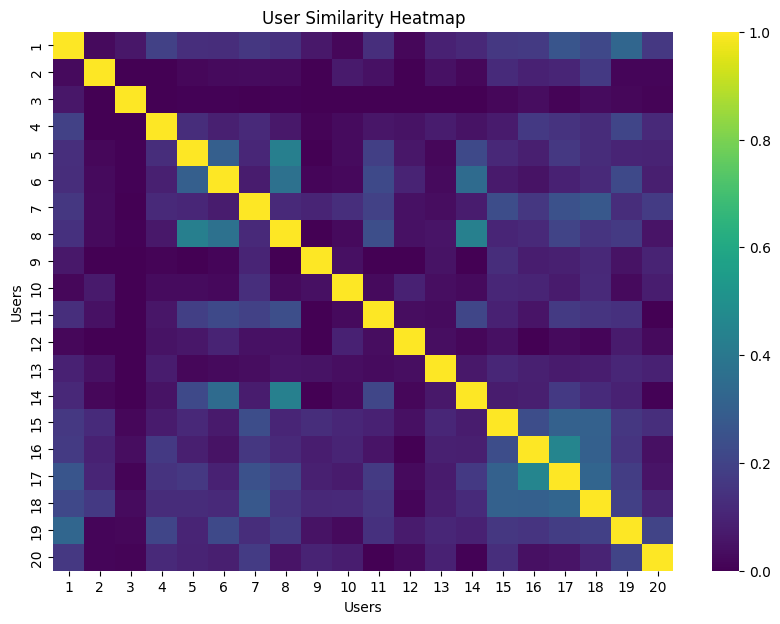

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    user_similarity_df.iloc[:20, :20],
    cmap="viridis"
)

plt.title("User Similarity Heatmap")
plt.xlabel("Users")
plt.ylabel("Users")

plt.show()

In [ ]:
def predict_rating(user_id, movie_id, k=10):

    # If movie doesn't exist in matrix
    if movie_id not in user_item_matrix.columns:
        return np.nan

    similarities = user_similarity_df[user_id].drop(user_id)

    # Users who rated this movie
    movie_ratings = user_item_matrix[movie_id].dropna()

    # Keep only users who rated the movie
    common_users = similarities.index.intersection(
        movie_ratings.index
    )

    if len(common_users) == 0:
        return np.nan

    # Select top similar users
    top_users = similarities.loc[common_users].sort_values(
        ascending=False
    ).head(k)

    ratings_for_movie = movie_ratings.loc[top_users.index]

    # Weighted average
    denominator = np.abs(top_users).sum()

    if denominator == 0:
        return np.nan

    predicted_rating = (
        (top_users * ratings_for_movie).sum()
        / denominator
    )

    return predicted_rating

In [ ]:
# Example prediction

prediction = predict_rating(1, 50)

print("Predicted rating:", prediction)

Predicted rating: 4.59545619361934


In [ ]:
# Example prediction

prediction = predict_rating(8, 70)

print("Predicted rating:", prediction)

Predicted rating: 3.7062352879993052


This project developed a movie recommendation system using the MovieLens dataset and collaborative filtering.

The raw rating data was transformed into a user-item matrix where users represent rows, movies represent columns, and ratings represent interactions.

Due to the large number of unrated user-movie combinations, the matrix was highly sparse.

User-based collaborative filtering was implemented using cosine similarity to identify users with similar preferences.

The preferences of similar users were then used to generate personalized Top-N movie recommendations.

The system demonstrates how historical user-item interactions can be used to provide personalized recommendations without requiring detailed movie-content information.